In [1]:
import ocha_stratus as stratus
import geopandas as gpd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import pandas as pd
load_dotenv()

PCODES = ['NG008008', 'NG008015', 'NG008019', 'NG008025']

In [2]:
gdf_lga_sel = stratus.load_geoparquet_from_blob(
    "ds-aa-nga-flooding/processed/selected_lgas_borno.parquet"
)

## Land cover class distribution per LGA

Count ESA WorldCover pixels per class for each selected LGA.

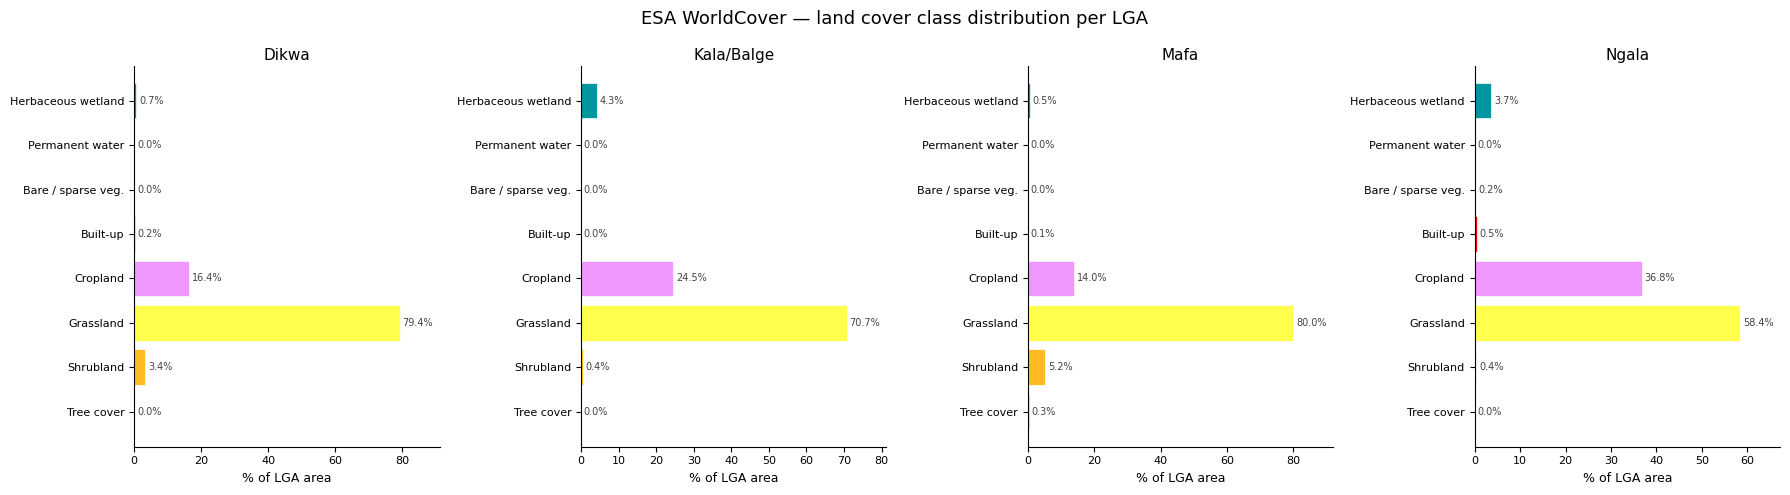

In [ ]:
import rasterio
from rasterio.mask import mask as rasterio_mask
import numpy as np

WORLDCOVER_PATH = "shapefiles/worldcover_borno.tif"

WC_CLASSES = {
    10:  ("Tree cover",            "#006400"),
    20:  ("Shrubland",             "#FFBB22"),
    30:  ("Grassland",             "#FFFF4C"),
    40:  ("Cropland",              "#F096FF"),
    50:  ("Built-up",              "#FA0000"),
    60:  ("Bare / sparse veg.",    "#B4B4B4"),
    70:  ("Snow and ice",          "#F0F0F0"),
    80:  ("Permanent water",       "#0064C8"),
    90:  ("Herbaceous wetland",    "#0096A0"),
    95:  ("Mangroves",             "#00CF75"),
    100: ("Moss and lichen",       "#FAE6A0"),
}

gdf_plot = gdf_lga_sel[gdf_lga_sel["ADM2_PCODE"].isin(PCODES)].copy()

# Extract pixel counts per class per LGA
lga_counts = {}
with rasterio.open(WORLDCOVER_PATH) as src:
    nodata_val = src.nodata if src.nodata is not None else 0
    for _, row in gdf_plot.iterrows():
        geom = [row.geometry.__geo_interface__]
        out_image, _ = rasterio_mask(src, geom, crop=True)
        data = out_image[0]
        data = data[data != nodata_val]
        vals, counts = np.unique(data, return_counts=True)
        lga_counts[row["ADM2_PCODE"]] = dict(zip(vals.tolist(), counts.tolist()))

# One subplot per LGA
n = len(gdf_plot)
fig, axes = plt.subplots(1, n, figsize=(n * 4.5, 5), squeeze=False)

for ax, (_, row) in zip(axes[0], gdf_plot.iterrows()):
    pcode = row["ADM2_PCODE"]
    counts = lga_counts.get(pcode, {})

    total = sum(counts.values())
    classes = [c for c in WC_CLASSES if c in counts]
    labels  = [WC_CLASSES[c][0] for c in classes]
    colors  = [WC_CLASSES[c][1] for c in classes]
    values  = [counts[c] / total * 100 for c in classes]

    bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xlim(0, max(values) * 1.15)
    for bar, val in zip(bars, values):
        ax.text(val + max(values) * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", fontsize=7, color="#444444")

    ax.set_title(row["ADM2_EN"], fontsize=11, pad=4)
    ax.set_xlabel("% of LGA area", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("ESA WorldCover — land cover class distribution per LGA", fontsize=13)
plt.tight_layout()
plt.savefig("figures/esa_worldcover_lga_distribution.png", dpi=300)


## JRC Global Surface Water distribution per LGA

**Occurrence** (0–100 %): fraction of time each pixel was observed as water. **Seasonality** (0–12 months): number of months per year water was present. Both plots exclude no-data (255) and zero-value pixels to focus on areas where surface water actually occurs.

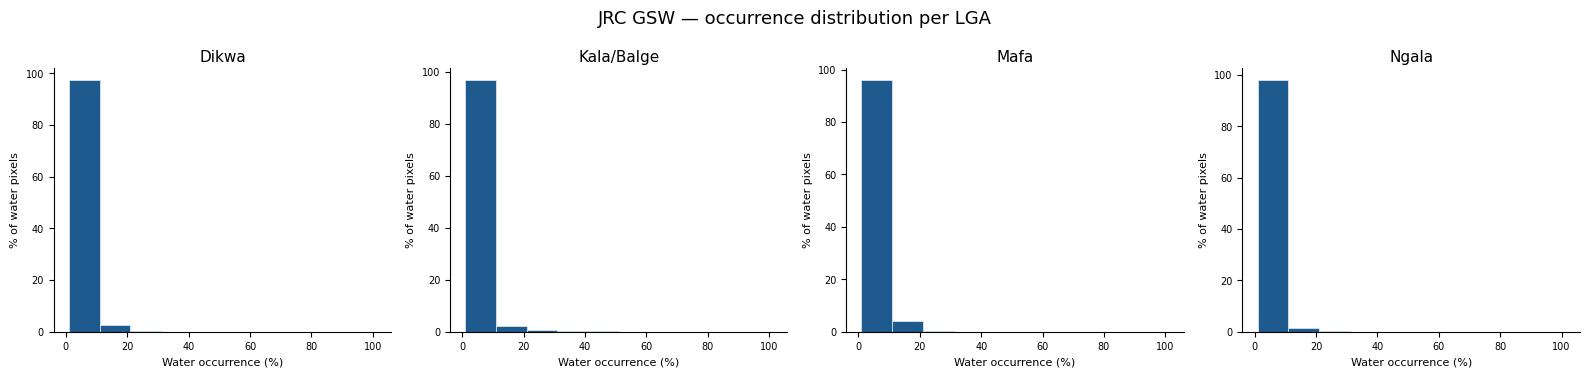

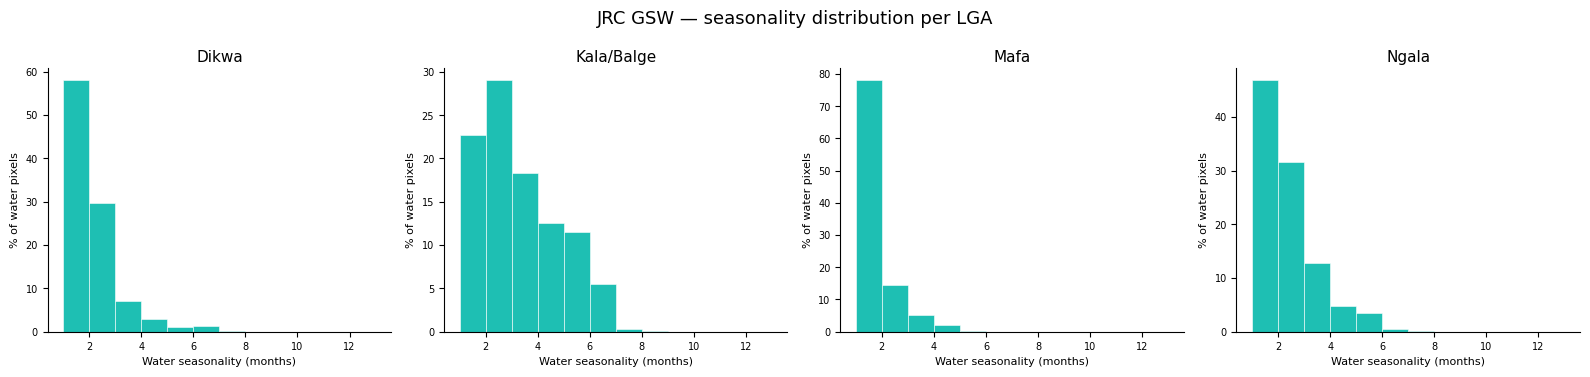

In [19]:
GSW_LAYERS = {
    "occurrence":  ("shapefiles/gsw_occurrence_borno.tif",  "Water occurrence (%)",        "#1E5A8E", 10, (1, 101)),
    "seasonality": ("shapefiles/gsw_seasonality_borno.tif", "Water seasonality (months)", "#1EBFB3",  1, (1,  13)),
}

gdf_plot = gdf_lga_sel[gdf_lga_sel["ADM2_PCODE"].isin(PCODES)].copy()
n = len(gdf_plot)

for layer_key, (path, xlabel, color, bin_width, val_range) in GSW_LAYERS.items():
    bins = np.arange(val_range[0], val_range[1] + bin_width, bin_width)

    fig, axes = plt.subplots(1, n, figsize=(n * 4.0, 3.8), squeeze=False)

    with rasterio.open(path) as src:
        nodata_val = src.nodata if src.nodata is not None else 255
        for ax, (_, row) in zip(axes[0], gdf_plot.iterrows()):
            geom = [row.geometry.__geo_interface__]
            out_image, _ = rasterio_mask(src, geom, crop=True)
            data = out_image[0].astype(float)
            data = data[(data != nodata_val) & (data > 0) & (data < 200)]

            weights = np.ones_like(data) / len(data) * 100
            ax.hist(data, bins=bins, weights=weights, color=color, edgecolor="white", linewidth=0.4)
            ax.set_title(row["ADM2_EN"], fontsize=11, pad=4)
            ax.set_xlabel(xlabel, fontsize=8)
            ax.set_ylabel("% of water pixels", fontsize=8)
            ax.tick_params(labelsize=7)
            ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle(f"JRC GSW — {layer_key} distribution per LGA", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"figures/gsw_{layer_key}_lga_distribution.png", dpi=300)
    plt.show()


## Land cover of historically flooded areas

Intersect the Google historical inundation layer with ESA WorldCover to identify which land cover types have been flooded. Two views:
1. Land cover composition of the flood footprint (what was flooded)
2. Share of each land cover class that sits within the flood footprint (relative exposure)

In [30]:
from rasterio.features import geometry_mask

gdf_inundation = stratus.load_geoparquet_from_blob(
    "ds-aa-nga-flooding/processed/google_inundation_history/combined_nga.parquet"
)
if gdf_inundation.crs is None:
    gdf_inundation = gdf_inundation.set_crs("EPSG:4326")

gdf_plot = gdf_lga_sel[gdf_lga_sel["ADM2_PCODE"].isin(PCODES)].copy()

lga_all_counts = {}
lga_flood_counts = {}

with rasterio.open(WORLDCOVER_PATH) as src:
    nodata_val = src.nodata if src.nodata is not None else 0

    # Align inundation and LGA geometries to WorldCover CRS
    gdf_inund = gdf_inundation.to_crs(src.crs)
    gdf_lgas  = gdf_plot.to_crs(src.crs)

    for _, row in gdf_lgas.iterrows():
        pcode    = row["ADM2_PCODE"]
        lga_geom = [row.geometry.__geo_interface__]

        out_image, out_transform = rasterio_mask(src, lga_geom, crop=True)
        data       = out_image[0]
        valid_mask = data != nodata_val

        # All-pixel class counts for this LGA
        vals, counts = np.unique(data[valid_mask], return_counts=True)
        lga_all_counts[pcode] = dict(zip(vals.tolist(), counts.tolist()))

        # Clip inundation polygons to LGA boundary
        inund_clip = gdf_inund[gdf_inund.intersects(row.geometry)].copy()
        inund_clip["geometry"] = inund_clip.geometry.intersection(row.geometry)
        inund_clip = inund_clip[~inund_clip.geometry.is_empty]

        if inund_clip.empty:
            lga_flood_counts[pcode] = {}
            continue

        # Burn inundation polygons onto the cropped WorldCover grid
        flood_mask = geometry_mask(
            [g.__geo_interface__ for g in inund_clip.geometry],
            transform=out_transform,
            invert=True,
            out_shape=data.shape,
        )

        flooded_pixels = data[flood_mask & valid_mask]
        if flooded_pixels.size == 0:
            lga_flood_counts[pcode] = {}
            continue

        vals_f, counts_f = np.unique(flooded_pixels, return_counts=True)
        lga_flood_counts[pcode] = dict(zip(vals_f.tolist(), counts_f.tolist()))

print("Done. Flooded pixel counts per LGA:")
for pcode, counts in lga_flood_counts.items():
    lga = gdf_plot.loc[gdf_plot["ADM2_PCODE"] == pcode, "ADM2_EN"].iloc[0]
    print(f"  {lga}: {sum(counts.values()):,} flooded pixels")

Done. Flooded pixel counts per LGA:
  Dikwa: 7,386,301 flooded pixels
  Kala/Balge: 15,989,818 flooded pixels
  Mafa: 7,956,904 flooded pixels
  Ngala: 9,149,300 flooded pixels


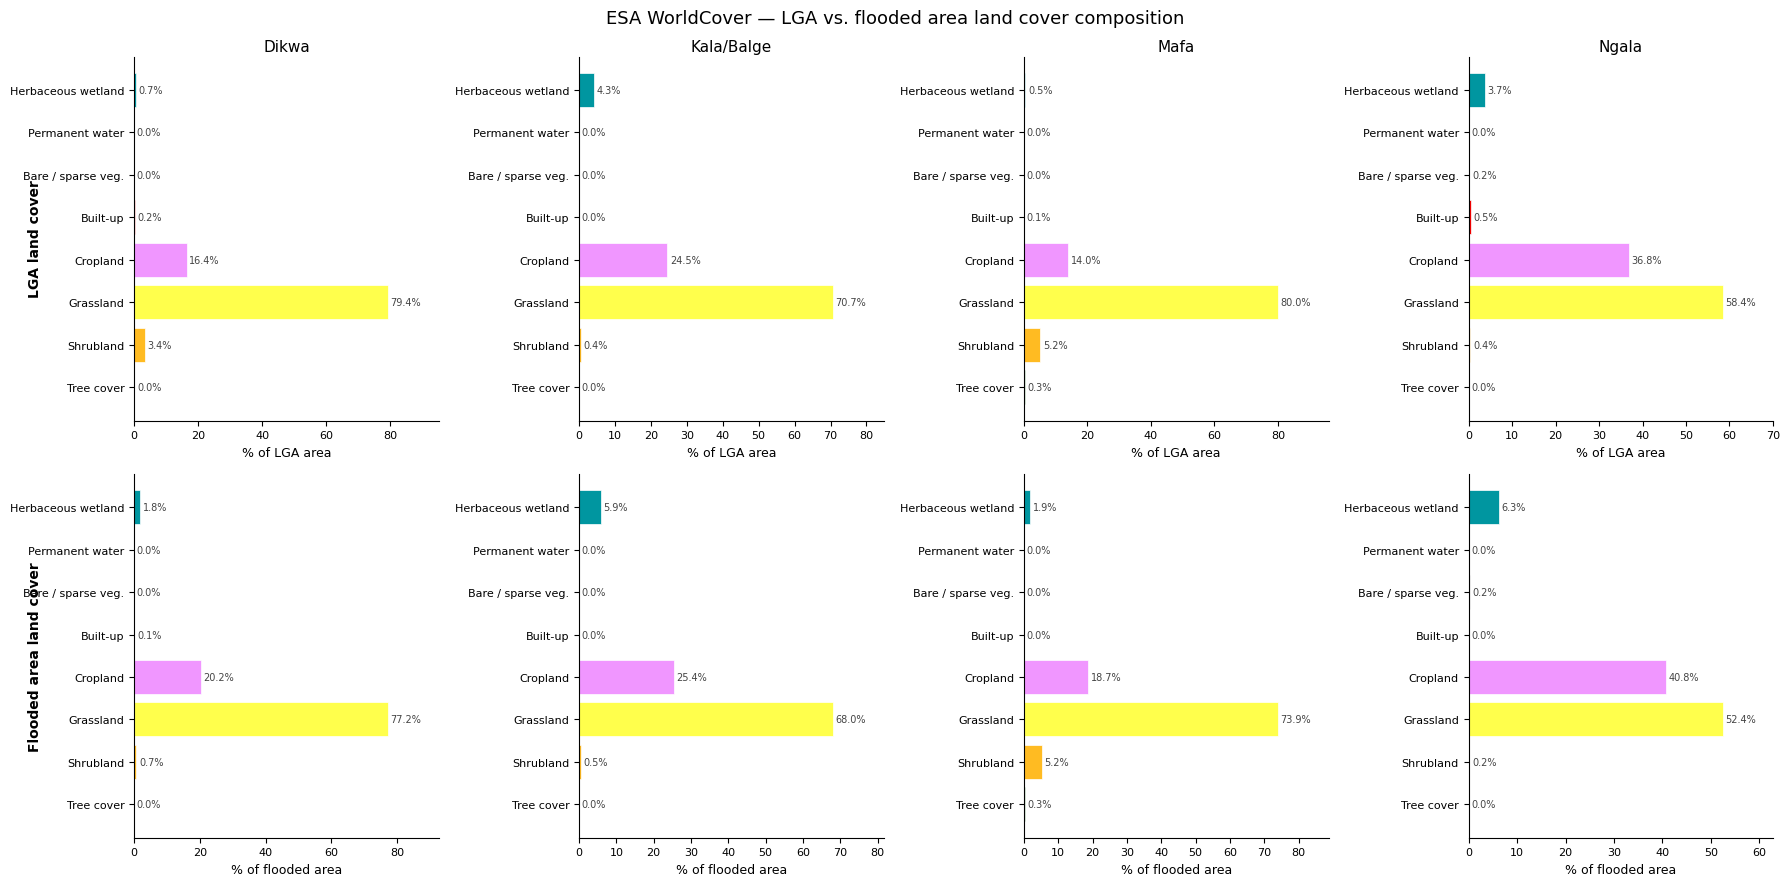

In [31]:
n = len(gdf_plot)

fig, all_axes = plt.subplots(2, n, figsize=(n * 4.5, 9), squeeze=False)

for col, (_, row) in enumerate(gdf_plot.iterrows()):
    pcode        = row["ADM2_PCODE"]
    all_counts   = lga_all_counts.get(pcode, {})
    flood_counts = lga_flood_counts.get(pcode, {})
    total_all    = sum(all_counts.values())
    total_flooded = sum(flood_counts.values())

    for ax_row, (counts, total, xlabel) in enumerate([
        (all_counts,   total_all,    "% of LGA area"),
        (flood_counts, total_flooded, "% of flooded area"),
    ]):
        ax = all_axes[ax_row, col]

        if total == 0:
            ax.axis("off")
            if ax_row == 0:
                ax.set_title(row["ADM2_EN"], fontsize=11)
            continue

        classes = [c for c in WC_CLASSES if c in counts]
        labels  = [WC_CLASSES[c][0] for c in classes]
        colors  = [WC_CLASSES[c][1] for c in classes]
        values  = [counts[c] / total * 100 for c in classes]

        bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=0.5)
        xmax = max(values)
        ax.set_xlim(0, xmax * 1.2)
        for bar, val in zip(bars, values):
            ax.text(val + xmax * 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}%", va="center", fontsize=7, color="#444444")
        if ax_row == 0:
            ax.set_title(row["ADM2_EN"], fontsize=11, pad=4)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.tick_params(labelsize=8)
        ax.spines[["top", "right"]].set_visible(False)

all_axes[0, 0].annotate("LGA land cover", xy=(-0.35, 0.5), xycoords="axes fraction",
                         fontsize=10, fontweight="bold", rotation=90, va="center")
all_axes[1, 0].annotate("Flooded area land cover", xy=(-0.35, 0.5), xycoords="axes fraction",
                         fontsize=10, fontweight="bold", rotation=90, va="center")

fig.suptitle("ESA WorldCover — LGA vs. flooded area land cover composition", fontsize=13)
plt.tight_layout()
plt.savefig("figures/worldcover_lga_vs_flooded.png", dpi=300)
plt.show()